# Analisando output do sequenciador

### Quais sao os outputs?

In [ ]:
# https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://www.10xgenomics.com/support/software/space-ranger/2.1/getting-started&ved=2ahUKEwjG1cnp75WUAxVjr5UCHezGEQ4QFnoECBwQAQ&usg=AOvVaw0SPGEwhTGpenrX3bxjxxlK

In [2]:
# web_summary.html
# | QC geral do experimento
# \ % mapeamento, genes/spot, saturação

# filtered_feature_bc_matrix/
# | matriz principal (USAR)
# \ genes x spots (já filtrado)

# raw_feature_bc_matrix/
# | matriz bruta
# \ inclui spots ruins

# spatial/
# | localização dos spots
# \ coordenadas + imagens

# analysis/
# | PCA / UMAP / clusters
# \ (geralmente refazer)

# metrics_summary.csv
# | métricas em tabela
# \ útil pra comparar amostras

In [ ]:
# web_summary → qualidade?
#       ↓
# filtered_matrix → análise
#       ↓
# spatial → plot no tecido

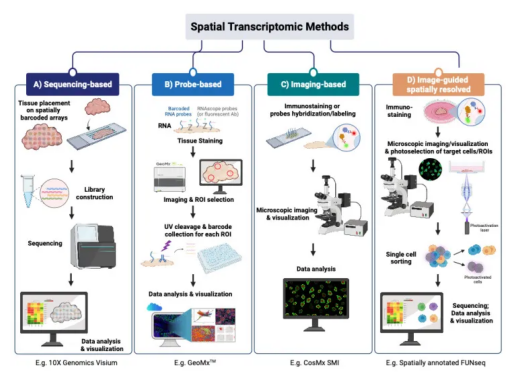

In [3]:
import imageio.v3 as iio
import matplotlib.pyplot as plt

img = iio.imread("/app/imgs/methods.png")

plt.imshow(img)
plt.axis("off")
plt.show()

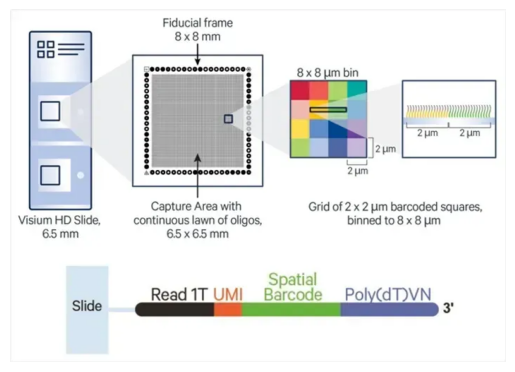

In [7]:
import imageio.v3 as iio
import matplotlib.pyplot as plt

img = iio.imread("/mnt/SATA/spatialCourse/imgs/spatialSlide.png")

plt.imshow(img)
plt.axis("off")
plt.show()

# Analisando um arquivo inicialmente

In [2]:
import spatools as st
adata = st.read("/mnt/SATA/spatialCourse/data/FB_P26_S4.h5ad")

## grande diferenca do spatools pro scanpy na leitura
#### Geracao do library_id ja na leitura com base no nome do arquivo e alinhamento do nome da imagem com o nome do arquivo, facilitando a analise de multiplos dados.

In [2]:
adata.obs

,in_tissue,array_row,array_col,library_id,selected_area
AAACAACGAATAGTTC-1,1,0,16,FB_P26_S4,Not selected
AAACAAGTATCTCCCA-1,1,50,102,FB_P26_S4,Not selected
AAACAATCTACTAGCA-1,1,3,43,FB_P26_S4,Not selected
AAACAGAGCGACTCCT-1,1,14,94,FB_P26_S4,Not selected
AAACAGCTTTCAGAAG-1,1,43,9,FB_P26_S4,Not selected
...,...,...,...,...,...
TTGTTCAGTGTGCTAC-1,1,24,64,FB_P26_S4,Not selected
TTGTTCTAGATACGCT-1,1,21,3,FB_P26_S4,Not selected
TTGTTGTGTGTCAAGA-1,1,31,77,FB_P26_S4,Not selected
TTGTTTCCATACAACT-1,1,45,27,FB_P26_S4,Not selected


In [4]:
adata.var

,gene_ids,feature_types,genome,n_cells
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,11
AL627309.5,ENSG00000241860,Gene Expression,GRCh38,3
AL732372.1,ENSG00000236601,Gene Expression,GRCh38,8
AL669831.2,ENSG00000229905,Gene Expression,GRCh38,2
LINC01409,ENSG00000237491,Gene Expression,GRCh38,91
...,...,...,...,...
AC011043.1,ENSG00000276256,Gene Expression,GRCh38,46
AL592183.1,ENSG00000273748,Gene Expression,GRCh38,3
AC240274.1,ENSG00000271254,Gene Expression,GRCh38,7
AC007325.4,ENSG00000278817,Gene Expression,GRCh38,77


In [5]:
adata.uns.keys()

dict_keys(['spatial'])

In [6]:
adata.uns

{'spatial': {'FB_P26_S4': {'images': {'hires': array([[[0.77254903, 0.7764706 , 0.77254903],
            [0.77254903, 0.7764706 , 0.77254903],
            [0.77254903, 0.77254903, 0.76862746],
            ...,
            [0.7647059 , 0.76862746, 0.7647059 ],
            [0.7647059 , 0.76862746, 0.7647059 ],
            [0.76862746, 0.76862746, 0.7647059 ]],
    
           [[0.77254903, 0.77254903, 0.77254903],
            [0.77254903, 0.77254903, 0.76862746],
            [0.77254903, 0.7764706 , 0.76862746],
            ...,
            [0.7647059 , 0.76862746, 0.7647059 ],
            [0.7647059 , 0.76862746, 0.7647059 ],
            [0.7647059 , 0.77254903, 0.76862746]],
    
           [[0.77254903, 0.77254903, 0.76862746],
            [0.77254903, 0.77254903, 0.76862746],
            [0.77254903, 0.77254903, 0.76862746],
            ...,
            [0.76862746, 0.77254903, 0.76862746],
            [0.7647059 , 0.76862746, 0.7647059 ],
            [0.7647059 , 0.76862746, 0.76470

In [7]:
adata.uns["spatial"].keys() # mesmo do nome do arquivo e em adata.obs["library_id"]

dict_keys(['FB_P26_S4'])

In [8]:
adata.uns["spatial"]['FB_P26_S4']

{'images': {'hires': array([[[0.77254903, 0.7764706 , 0.77254903],
          [0.77254903, 0.7764706 , 0.77254903],
          [0.77254903, 0.77254903, 0.76862746],
          ...,
          [0.7647059 , 0.76862746, 0.7647059 ],
          [0.7647059 , 0.76862746, 0.7647059 ],
          [0.76862746, 0.76862746, 0.7647059 ]],
  
         [[0.77254903, 0.77254903, 0.77254903],
          [0.77254903, 0.77254903, 0.76862746],
          [0.77254903, 0.7764706 , 0.76862746],
          ...,
          [0.7647059 , 0.76862746, 0.7647059 ],
          [0.7647059 , 0.76862746, 0.7647059 ],
          [0.7647059 , 0.77254903, 0.76862746]],
  
         [[0.77254903, 0.77254903, 0.76862746],
          [0.77254903, 0.77254903, 0.76862746],
          [0.77254903, 0.77254903, 0.76862746],
          ...,
          [0.76862746, 0.77254903, 0.76862746],
          [0.7647059 , 0.76862746, 0.7647059 ],
          [0.7647059 , 0.76862746, 0.7647059 ]],
  
         ...,
  
         [[0.77254903, 0.7764706 , 0.772549

In [9]:
adata.uns["spatial"]['FB_P26_S4'].keys()

dict_keys(['images', 'metadata', 'scalefactors'])

## images

In [10]:
adata.uns["spatial"]['FB_P26_S4']["images"]

{'hires': array([[[0.77254903, 0.7764706 , 0.77254903],
         [0.77254903, 0.7764706 , 0.77254903],
         [0.77254903, 0.77254903, 0.76862746],
         ...,
         [0.7647059 , 0.76862746, 0.7647059 ],
         [0.7647059 , 0.76862746, 0.7647059 ],
         [0.76862746, 0.76862746, 0.7647059 ]],
 
        [[0.77254903, 0.77254903, 0.77254903],
         [0.77254903, 0.77254903, 0.76862746],
         [0.77254903, 0.7764706 , 0.76862746],
         ...,
         [0.7647059 , 0.76862746, 0.7647059 ],
         [0.7647059 , 0.76862746, 0.7647059 ],
         [0.7647059 , 0.77254903, 0.76862746]],
 
        [[0.77254903, 0.77254903, 0.76862746],
         [0.77254903, 0.77254903, 0.76862746],
         [0.77254903, 0.77254903, 0.76862746],
         ...,
         [0.76862746, 0.77254903, 0.76862746],
         [0.7647059 , 0.76862746, 0.7647059 ],
         [0.7647059 , 0.76862746, 0.7647059 ]],
 
        ...,
 
        [[0.77254903, 0.7764706 , 0.77254903],
         [0.77254903, 0.7764706 

In [11]:
adata.uns["spatial"]['FB_P26_S4']["images"].keys() # geralemnte se tem o hires e o lowers que correspondem a diferentes FOVs

dict_keys(['hires'])

In [12]:
adata.uns["spatial"]['FB_P26_S4']["images"]["hires"] # array da imagem propriamente dita

array([[[0.77254903, 0.7764706 , 0.77254903],
        [0.77254903, 0.7764706 , 0.77254903],
        [0.77254903, 0.77254903, 0.76862746],
        ...,
        [0.7647059 , 0.76862746, 0.7647059 ],
        [0.7647059 , 0.76862746, 0.7647059 ],
        [0.76862746, 0.76862746, 0.7647059 ]],

       [[0.77254903, 0.77254903, 0.77254903],
        [0.77254903, 0.77254903, 0.76862746],
        [0.77254903, 0.7764706 , 0.76862746],
        ...,
        [0.7647059 , 0.76862746, 0.7647059 ],
        [0.7647059 , 0.76862746, 0.7647059 ],
        [0.7647059 , 0.77254903, 0.76862746]],

       [[0.77254903, 0.77254903, 0.76862746],
        [0.77254903, 0.77254903, 0.76862746],
        [0.77254903, 0.77254903, 0.76862746],
        ...,
        [0.76862746, 0.77254903, 0.76862746],
        [0.7647059 , 0.76862746, 0.7647059 ],
        [0.7647059 , 0.76862746, 0.7647059 ]],

       ...,

       [[0.77254903, 0.7764706 , 0.77254903],
        [0.77254903, 0.7764706 , 0.77254903],
        [0.77254903, 0

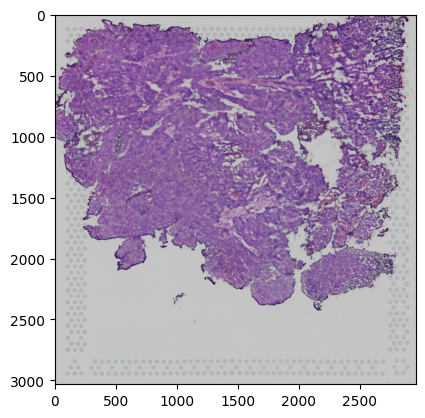

In [3]:
import matplotlib.pyplot as plt
plt.imshow(adata.uns["spatial"]['FB_P26_S4']["images"]["hires"])

## metadata

In [14]:
adata.uns["spatial"]['FB_P26_S4'].keys()

dict_keys(['images', 'metadata', 'scalefactors'])

In [15]:
adata.uns["spatial"]['FB_P26_S4']["metadata"] # json

{'chemistry_description': 'Visium V1 Slide',
 'software_version': 'spaceranger-2.0.0'}

## scalefactors

In [4]:
adata.obs

,in_tissue,array_row,array_col,library_id,selected_area
AAACAACGAATAGTTC-1,1,0,16,FB_P26_S4,Not selected
AAACAAGTATCTCCCA-1,1,50,102,FB_P26_S4,Not selected
AAACAATCTACTAGCA-1,1,3,43,FB_P26_S4,Not selected
AAACAGAGCGACTCCT-1,1,14,94,FB_P26_S4,Not selected
AAACAGCTTTCAGAAG-1,1,43,9,FB_P26_S4,Not selected
...,...,...,...,...,...
TTGTTCAGTGTGCTAC-1,1,24,64,FB_P26_S4,Not selected
TTGTTCTAGATACGCT-1,1,21,3,FB_P26_S4,Not selected
TTGTTGTGTGTCAAGA-1,1,31,77,FB_P26_S4,Not selected
TTGTTTCCATACAACT-1,1,45,27,FB_P26_S4,Not selected


In [16]:
adata.uns["spatial"]['FB_P26_S4']['scalefactors']

{'fiducial_diameter_fullres': 39.26193798825616,
 'spot_diameter_fullres': 24.30500923082524,
 'tissue_hires_scalef': 0.6596306,
 'tissue_lowres_scalef': 0.19788918}

## image coordenates

In [5]:
adata.obsm

AxisArrays with keys: spatial

In [6]:
adata.obsm["spatial"]

array([[ 603,  282],
       [2211, 1907],
       [1107,  379],
       ...,
       [1744, 1289],
       [ 809, 1745],
       [1257,  509]], shape=(3504, 2))

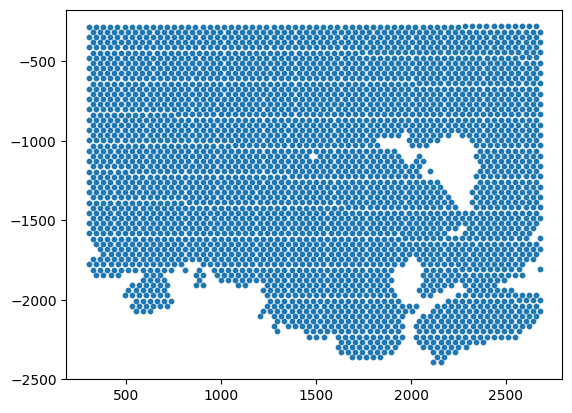

In [ ]:
import matplotlib.pyplot as plt
s = 10
plt.scatter(adata.obsm['spatial'][:,0], adata.obsm['spatial'][:,1], s=s) # TODO: change the s value

/mnt/SATA/spatialCourse/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


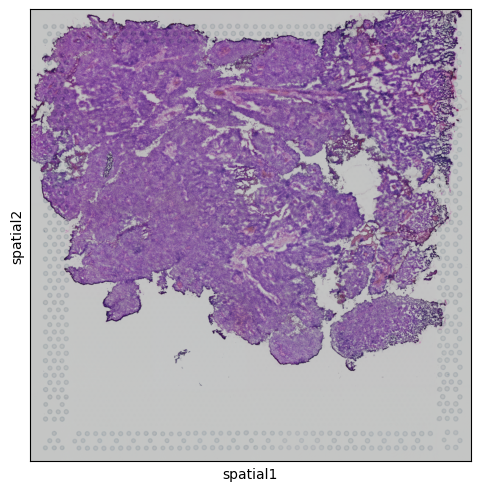

In [10]:
import squidpy as sq
sq.pl.spatial_scatter(adata) # TODO: change the size value

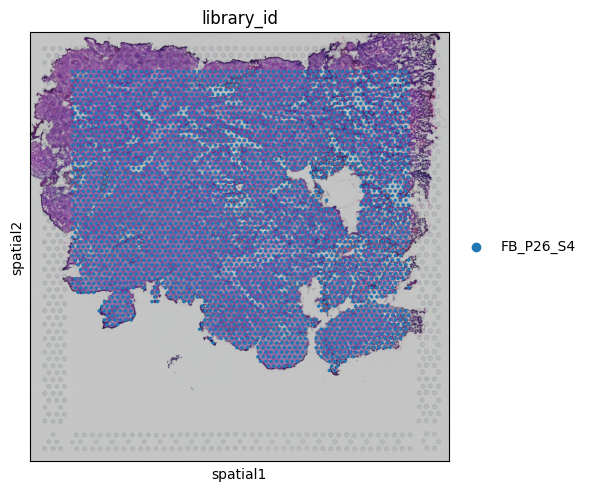

In [14]:
sq.pl.spatial_scatter(adata, color="library_id", scale_factor=0.998)

# Expression Matrix

In [15]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 6999278 stored elements and shape (3504, 22844)>

In [16]:
import numpy as np
print(np.array(adata.X)) # exp_matrix

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 6999278 stored elements and shape (3504, 22844)>
  Coords	Values
  (0, 13)	1.0
  (0, 14)	1.0
  (0, 18)	1.0
  (0, 20)	1.0
  (0, 28)	1.0
  (0, 32)	1.0
  (0, 35)	1.0
  (0, 37)	1.0
  (0, 50)	1.0
  (0, 55)	2.0
  (0, 67)	1.0
  (0, 68)	1.0
  (0, 102)	1.0
  (0, 119)	9.0
  (0, 139)	3.0
  (0, 156)	6.0
  (0, 162)	1.0
  (0, 179)	1.0
  (0, 181)	1.0
  (0, 186)	1.0
  (0, 189)	1.0
  (0, 203)	1.0
  (0, 205)	1.0
  (0, 210)	2.0
  (0, 224)	2.0
  :	:
  (3503, 22739)	4.0
  (3503, 22743)	1.0
  (3503, 22767)	2.0
  (3503, 22772)	1.0
  (3503, 22775)	1.0
  (3503, 22778)	1.0
  (3503, 22779)	1.0
  (3503, 22780)	5.0
  (3503, 22783)	6.0
  (3503, 22787)	1.0
  (3503, 22795)	1.0
  (3503, 22804)	1.0
  (3503, 22810)	1.0
  (3503, 22816)	1.0
  (3503, 22823)	5.0
  (3503, 22824)	2.0
  (3503, 22825)	16.0
  (3503, 22826)	20.0
  (3503, 22828)	13.0
  (3503, 22829)	28.0
  (3503, 22830)	6.0
  (3503, 22832)	16.0
  (3503, 22833)	4.0
  (3503, 22834)	1.0
  (3503, 22835)	9.0

In [19]:
adata.layers # stores modified exp_matrix that you usualy store to use in the future

Layers with keys: 